In [1]:
                                                            # NumPy, Pandas, Matplotlib #
                                                                    # ASSESSMENT#

In [3]:
# Q.(1) Import pandas and read in the banklist.csv file into a dataframe called banks.

import pandas as pd 
banks = pd.read_csv('banklist.csv')
banks

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",26-May-17,26-Jul-17
1,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,5-May-17,26-Jul-17
2,First NBC Bank,New Orleans,LA,58302,Whitney Bank,28-Apr-17,26-Jul-17
3,Proficio Bank,Cottonwood Heights,UT,35495,Cache Valley Bank,3-Mar-17,18-May-17
4,Seaway Bank and Trust Company,Chicago,IL,19328,State Bank of Texas,27-Jan-17,18-May-17
...,...,...,...,...,...,...,...
548,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,19-Aug-14
549,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,18-Nov-02
550,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,18-Feb-03
551,National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,17-Mar-05


In [5]:
# Q.(2) Show the head of the dataframe.
banks.head()

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",26-May-17,26-Jul-17
1,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,5-May-17,26-Jul-17
2,First NBC Bank,New Orleans,LA,58302,Whitney Bank,28-Apr-17,26-Jul-17
3,Proficio Bank,Cottonwood Heights,UT,35495,Cache Valley Bank,3-Mar-17,18-May-17
4,Seaway Bank and Trust Company,Chicago,IL,19328,State Bank of Texas,27-Jan-17,18-May-17


In [6]:
# Q.(3) What are the column names?
banks.columns

Index(['Bank Name', 'City', 'ST', 'CERT', 'Acquiring Institution',
       'Closing Date', 'Updated Date'],
      dtype='object')

In [8]:
# Q.(4) How many States (ST) are represented in this data set?
banks['ST'].nunique()

44

In [11]:
# Q.(5) Get a list or array of all the states in the data set.
banks['ST'].unique()

array(['IL', 'WI', 'LA', 'UT', 'NJ', 'AR', 'GA', 'PA', 'TN', 'WA', 'CO',
       'PR', 'FL', 'MN', 'CA', 'MD', 'OK', 'OH', 'SC', 'VA', 'ID', 'TX',
       'CT', 'AZ', 'NV', 'NC', 'KY', 'MO', 'KS', 'AL', 'MI', 'IN', 'IA',
       'NE', 'MS', 'NM', 'OR', 'NY', 'MA', 'SD', 'WY', 'WV', 'NH', 'HI'],
      dtype=object)

In [12]:
# Q.(6) What are the top 5 states with the most failed banks?
banks['ST'].value_counts().head(5)

ST
GA    93
FL    75
IL    68
CA    41
MN    23
Name: count, dtype: int64

In [17]:
# Q.(7) What are the top 5 acquiring institutions?
# Assuming the column name is'acquiring institutions'
banks['Acquiring Institution'].value_counts().head(5)

Acquiring Institution
No Acquirer                            31
State Bank and Trust Company           12
First-Citizens Bank & Trust Company    11
Ameris Bank                            10
U.S. Bank N.A.                          9
Name: count, dtype: int64

In [18]:
# Q.(8) How many banks has the State Bank of Texas acquired? How many of them were actually in Texas?
# Total acquisitions by State Bank of Texas
total_acquired = banks[banks['Acquiring Institution'] == 'State Bank of Texas'].shape[0]
print(f"Total acquired: {total_acquired}")

# How many of those were actually located in Texas (ST == 'TX')
in_texas = banks[(banks['Acquiring Institution'] == 'State Bank of Texas') & (banks['ST'] == 'TX')].shape[0]
print(f"Acquired in Texas: {in_texas}")

Total acquired: 3
Acquired in Texas: 1


In [19]:
# Q.(9) What is the most common city in California for a bank to fail in?
# Filters for California ('CA') and finds the most frequent city
banks[banks['ST'] == 'CA']['City'].value_counts().idxmax()

'Los Angeles'

In [20]:
                                                    # NumPy, Pandas, Matplotlib Libraries #
                                                                # Assessment 2 #

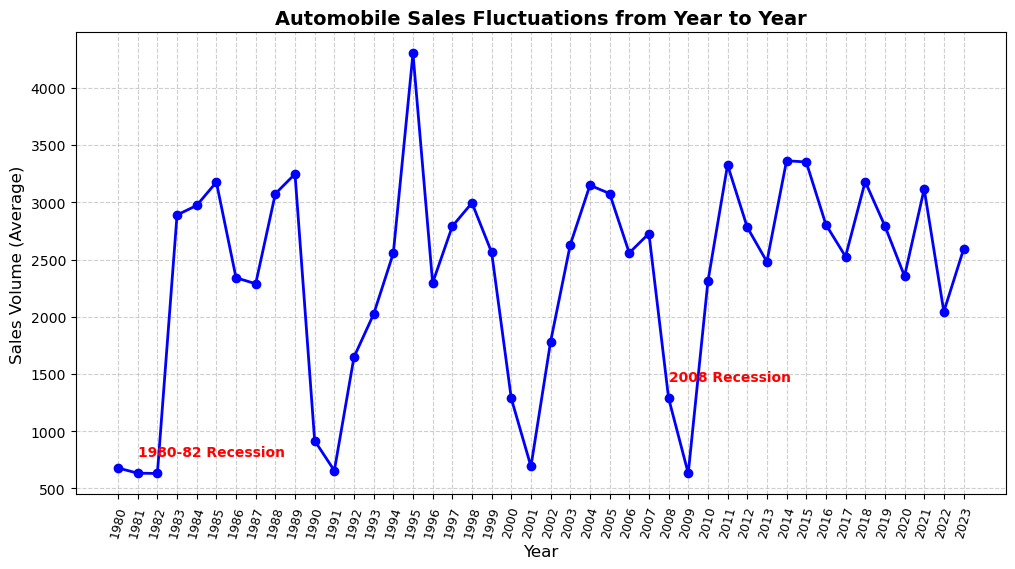

In [29]:
# Q.(1) Develop a Line chart using the functionality of pandas to show howautomobile sales fluctuate from year to year.
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('historical_automobile_sales.csv')

# 2. Group by 'Year' and calculate the mean of 'Automobile_Sales'
df_line = df.groupby('Year')['Automobile_Sales'].mean()

# 3. Create the line plot using Pandas plotting functionality (.plot())
# Setting figsize directly within the plot function as per best practices
ax = df_line.plot(kind='line', figsize=(12, 6), marker='o', linewidth=2, color='b')

# 4. Customize ticks, labels, and title
# Provide ticks for all years from 1980 to 2023 to clearly identify periods
plt.xticks(list(range(1980, 2024)), rotation=75, fontsize=9)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sales Volume (Average)', fontsize=12)
plt.title('Automobile Sales Fluctuations from Year to Year', fontsize=14, fontweight='bold')

# 5. Add a grid for easier readability of data points
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Optional: Add text annotations for key historical recession periods
# Adjust the y-coordinate (e.g., 650 or 1000) depending on your data scale
plt.text(1981, df_line.loc[1981] + 150, '1980-82 Recession', color='red', weight='bold', fontsize=10)
plt.text(2008, df_line.loc[2008] + 150, '2008 Recession', color='red', weight='bold', fontsize=10)

# 7. Save and display the visualization
plt.savefig('automobile_sales_fluctuation.png', bbox_inches='tight')
plt.show()

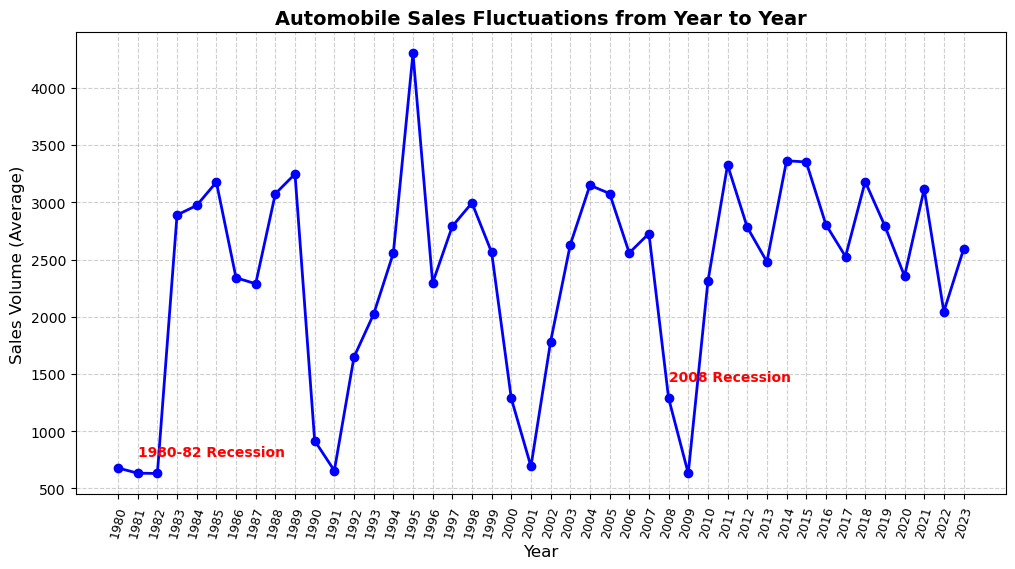

In [30]:
# Q.(2)Plot different lines for categories of vehicle type and analyze the trendto answer the question Is there a noticeable difference in sales trends
# between different vehicle types during recession periods? 

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('historical_automobile_sales.csv')

# 2. Group by 'Year' and calculate the mean of 'Automobile_Sales'
df_line = df.groupby('Year')['Automobile_Sales'].mean()

# 3. Create the line plot using Pandas plotting functionality (.plot())
# Setting figsize directly within the plot function as per best practices
ax = df_line.plot(kind='line', figsize=(12, 6), marker='o', linewidth=2, color='b')

# 4. Customize ticks, labels, and title
# Provide ticks for all years from 1980 to 2023 to clearly identify periods
plt.xticks(list(range(1980, 2024)), rotation=75, fontsize=9)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sales Volume (Average)', fontsize=12)
plt.title('Automobile Sales Fluctuations from Year to Year', fontsize=14, fontweight='bold')

# 5. Add a grid for easier readability of data points
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Optional: Add text annotations for key historical recession periods
# Adjust the y-coordinate (e.g., 650 or 1000) depending on your data scale
plt.text(1981, df_line.loc[1981] + 150, '1980-82 Recession', color='red', weight='bold', fontsize=10)
plt.text(2008, df_line.loc[2008] + 150, '2008 Recession', color='red', weight='bold', fontsize=10)

# 7. Save and display the visualization
plt.savefig('automobile_sales_fluctuation.png', bbox_inches='tight')
plt.show()

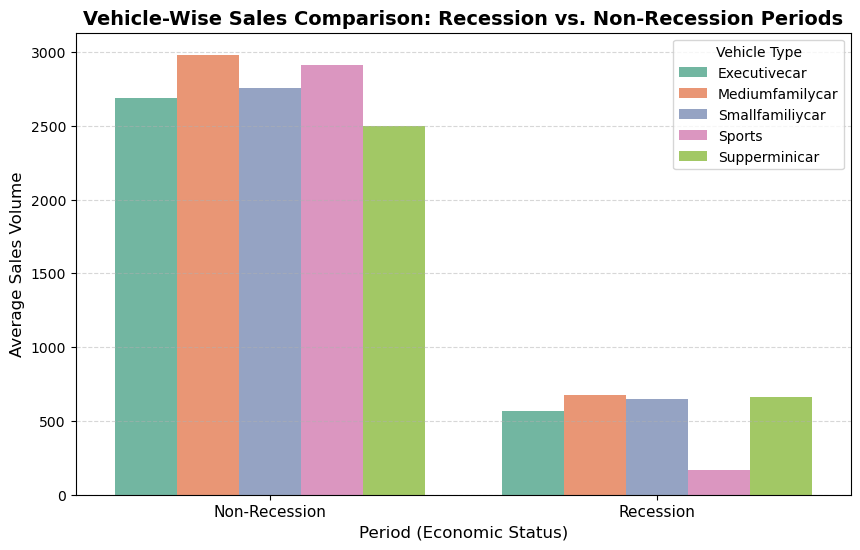

In [33]:
# Q.(3)Use the functionality of Seaborn Library to create a visualization to comparethe sales trend per vehicle type for a recession period 
# with a non- recession period. 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the historical automobile sales data
df = pd.read_csv('historical_automobile_sales.csv')

# 2. Group the data by 'Recession' and 'Vehicle_Type' and calculate the average sales
dd = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

# 3. Initialize the matplotlib figure
plt.figure(figsize=(10, 6))

# 4. Create the grouped bar chart using Seaborn's barplot functionality
# x='Recession' separates the periods, while hue='Vehicle_Type' places bars side-by-side
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=dd, palette='Set2')

# 5. Customize ticks, labels, and titles
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'], fontsize=11)
plt.xlabel('Period (Economic Status)', fontsize=12)
plt.ylabel('Average Sales Volume', fontsize=12)
plt.title('Vehicle-Wise Sales Comparison: Recession vs. Non-Recession Periods', fontsize=14, fontweight='bold')

# 6. Enhance plot readability
plt.legend(title='Vehicle Type', fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

# 7. Save and display the visualization
plt.savefig('sales_trend_per_vehicle_type.png', bbox_inches='tight')
plt.show()

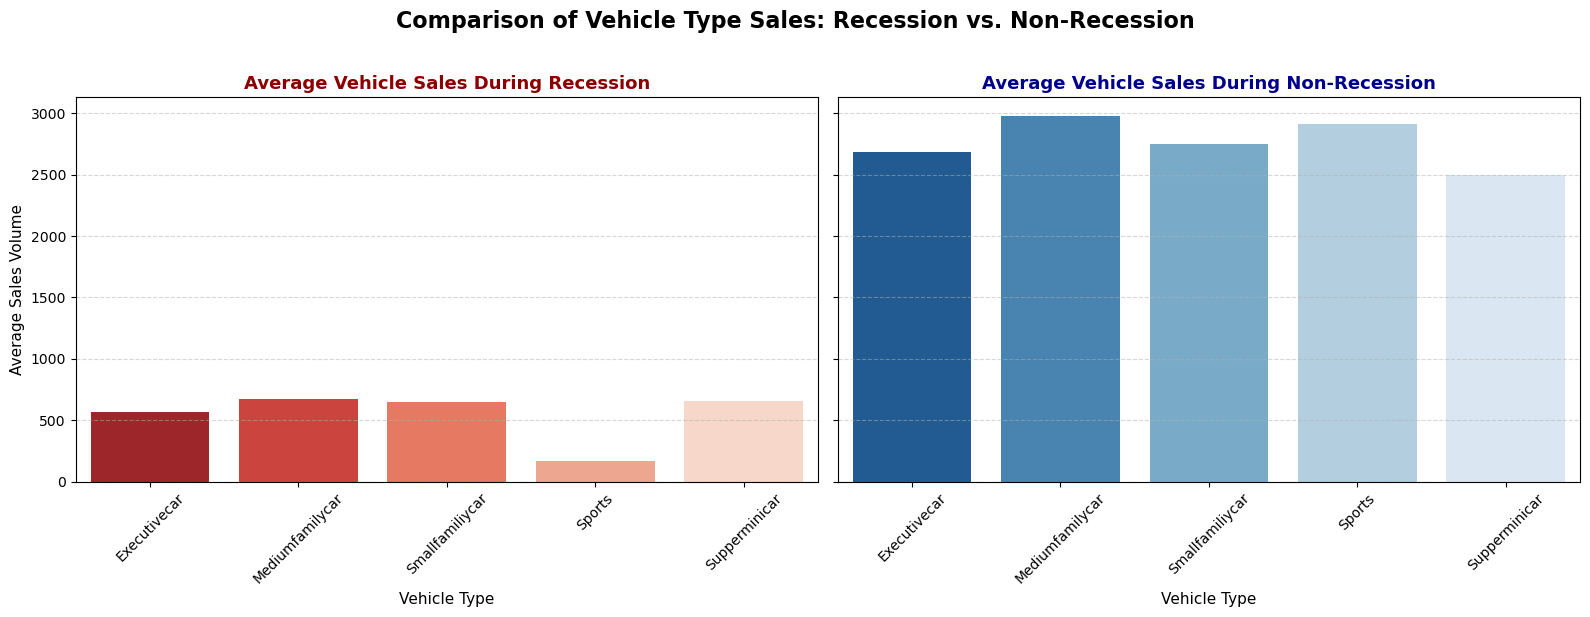

In [36]:
# Q.(4) Now you want to compare the sales of different vehicle typesduring a recession and a non-recession period 


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('historical_automobile_sales.csv')

# 2. Filter the dataset into two distinct DataFrames
recession_data = df[df['Recession'] == 1]
non_recession_data = df[df['Recession'] == 0]

# 3. Aggregate the data to find the mean sales for each vehicle type
recession_grouped = recession_data.groupby('Vehicle_Type')['Automobile_Sales'].mean().reset_index()
non_recession_grouped = non_recession_data.groupby('Vehicle_Type')['Automobile_Sales'].mean().reset_index()

# 4. Set up a 1-row, 2-column subplot structure sharing the same Y-axis scale
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Subplot 1: Recession Period ---
sns.barplot(
    x='Vehicle_Type', 
    y='Automobile_Sales', 
    data=recession_grouped, 
    ax=axes[0], 
    hue='Vehicle_Type',    # <-- Added to resolve the warning
    palette='Reds_r', 
    legend=False           # <-- Added to hide the redundant legend
)
axes[0].set_title('Average Vehicle Sales During Recession', fontsize=13, fontweight='bold', color='darkred')
axes[0].set_xlabel('Vehicle Type', fontsize=11)
axes[0].set_ylabel('Average Sales Volume', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.5, axis='y')

# --- Subplot 2: Non-Recession Period ---
sns.barplot(
    x='Vehicle_Type', 
    y='Automobile_Sales', 
    data=non_recession_grouped, 
    ax=axes[1], 
    hue='Vehicle_Type',    # <-- Added to resolve the warning
    palette='Blues_r', 
    legend=False           # <-- Added to hide the redundant legend
)
axes[1].set_title('Average Vehicle Sales During Non-Recession', fontsize=13, fontweight='bold', color='darkblue')
axes[1].set_xlabel('Vehicle Type', fontsize=11)
axes[1].set_ylabel('') 
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')

# 5. Global figure adjustments
plt.suptitle('Comparison of Vehicle Type Sales: Recession vs. Non-Recession', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# 6. Save and display the visualization
plt.savefig('recession_vs_non_recession_comparison.png', bbox_inches='tight')
plt.show()